In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Load both datasets and combine them
data_jan = pd.read_parquet("data/green_tripdata_2021-01.parquet")
data_feb = pd.read_parquet("data/green_tripdata_2021-02.parquet")
data = pd.concat([data_jan, data_feb], ignore_index=True)

In [2]:
#  DATA CLEANING

df = data.copy()

# 1. Drop columns that carry no useful information
# ehail_fee is entirely null across the whole dataset
df.drop(columns=['ehail_fee'], inplace=True)

# 2. Handle missing values
# Numeric columns with nulls → fill with median (robust to outliers)
num_fill = ['RatecodeID', 'passenger_count', 'payment_type',
            'trip_type', 'congestion_surcharge']
for col in num_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Filled '{col}' nulls with median ({median_val})")

# Categorical column → fill with mode
mode_val = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(mode_val)
print(f"  Filled 'store_and_fwd_flag' nulls with mode ('{mode_val}')")

# Drop any rows that still have non-finite values (inf / -inf)
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"\n  Dropped {before - len(df)} rows with remaining non-finite values.")

print(f"\nRemaining nulls after filling:\n{df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'None ✓'}")

# 3. Encode categorical features
# store_and_fwd_flag: binary  N → 0,  Y → 1
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1}).astype(int)
print("\nEncoded 'store_and_fwd_flag':  N → 0,  Y → 1")

# VendorID, RatecodeID, payment_type, trip_type are already integers;
# cast to int now that all NaNs are resolved
for col in ['VendorID', 'RatecodeID', 'payment_type', 'trip_type']:
    df[col] = df[col].astype(int)
print("Cast VendorID, RatecodeID, payment_type, trip_type → int")

# 4. Drop datetime columns (not used in modelling)
df.drop(columns=['lpep_pickup_datetime', 'lpep_dropoff_datetime'], inplace=True)
print("\nDropped datetime columns (not used in modelling).")

# Filter to realistic NYC taxi trip ranges
# total amount has to be bigger than 0 and less than 200 (big outliers)
# Same for passenger count
df = df[
    (df['total_amount'] > 0)   & (df['total_amount'] < 200) &
    (df['trip_distance'] > 0)   & (df['trip_distance'] < 60)  &
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)
].copy()

# 5. Final check
print(f"\nClean dataset shape: {df.shape}")
print("\nData types after cleaning:")
print(df.dtypes)
df.head()


  Filled 'RatecodeID' nulls with median (1.0)
  Filled 'passenger_count' nulls with median (1.0)
  Filled 'payment_type' nulls with median (1.0)
  Filled 'trip_type' nulls with median (1.0)
  Filled 'congestion_surcharge' nulls with median (0.0)
  Filled 'store_and_fwd_flag' nulls with mode ('N')

  Dropped 0 rows with remaining non-finite values.

Remaining nulls after filling:
None ✓

Encoded 'store_and_fwd_flag':  N → 0,  Y → 1
Cast VendorID, RatecodeID, payment_type, trip_type → int

Dropped datetime columns (not used in modelling).

Clean dataset shape: (136006, 17)

Data types after cleaning:
VendorID                   int64
store_and_fwd_flag         int64
RatecodeID                 int64
PULocationID               int64
DOLocationID               int64
passenger_count          float64
trip_distance            float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float6

,VendorID,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,0,1,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,0.3,6.80,2,1,0.00
1,2,0,1,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,0.3,16.86,1,1,2.75
2,2,0,1,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,0.3,8.30,1,1,0.00
3,2,0,1,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,0.3,9.30,2,1,0.00
7,2,0,1,75,75,6.0,0.45,3.5,0.5,0.5,0.96,0.0,0.3,5.76,1,1,0.00


In [3]:
# Prepare features and split combined dataset into train / test

df_model = pd.get_dummies(df, columns=['RatecodeID'], prefix='RatecodeID', drop_first=True)

ratecode_dummies = [c for c in df_model.columns if c.startswith('RatecodeID_')]
FEATURES = ['trip_distance', 'fare_amount', 'tip_amount'] + ratecode_dummies
TARGET   = 'total_amount'


print("One-hot encoded RatecodeID into columns:", ratecode_dummies)
print(f"Features used: {FEATURES}")

X = df_model[FEATURES]
y = df_model[TARGET]

# 80 / 20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")


One-hot encoded RatecodeID into columns: ['RatecodeID_2', 'RatecodeID_3', 'RatecodeID_4', 'RatecodeID_5']
Features used: ['trip_distance', 'fare_amount', 'tip_amount', 'RatecodeID_2', 'RatecodeID_3', 'RatecodeID_4', 'RatecodeID_5']

Train size : 108,804
Test  size : 27,202


Loaded existing model: LinearRegression()

=== Existing Model – Evaluation on Combined (Jan + Feb) Test Set ===
Features : ['trip_distance', 'fare_amount', 'tip_amount', 'RatecodeID_2', 'RatecodeID_3', 'RatecodeID_4', 'RatecodeID_5']
Target   : total_amount
MAE      : 1.4571
RMSE     : 1.9886
R²       : 0.9837


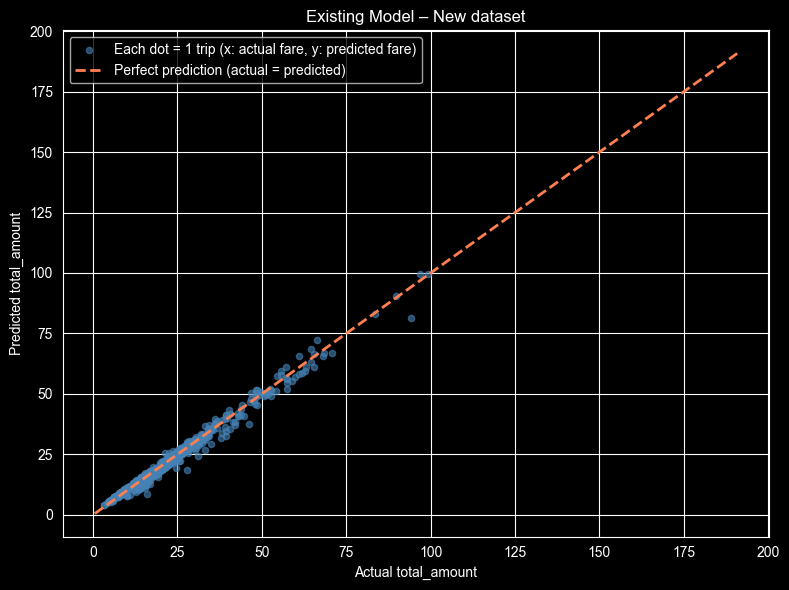

In [4]:
# Evaluate the EXISTING trained model (model.joblib) on the new combined test set
# The model is NOT retrained – we are testing how it generalises to new data.

existing_model = joblib.load("model.joblib")
print("Loaded existing model:", existing_model)

y_pred_existing = existing_model.predict(X_test)

mae_e  = mean_absolute_error(y_test, y_pred_existing)
rmse_e = np.sqrt(mean_squared_error(y_test, y_pred_existing))
r2_e   = r2_score(y_test, y_pred_existing)

print("\n=== Existing Model – Evaluation on Combined (Jan + Feb) Test Set ===")
print(f"Features : {FEATURES}")
print(f"Target   : {TARGET}")
print(f"MAE      : {mae_e:.4f}")
print(f"RMSE     : {rmse_e:.4f}")
print(f"R²       : {r2_e:.4f}")

# Predicted vs Actual plot
sample_idx = np.random.choice(len(y_test), size=500, replace=False)
y_test_sample = y_test.values[sample_idx]
y_pred_sample = y_pred_existing[sample_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_sample, y_pred_sample, alpha=0.6, s=20, color='steelblue',
           label='Each dot = 1 trip (x: actual fare, y: predicted fare)')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='coral', linewidth=2, linestyle='--', label='Perfect prediction (actual = predicted)')
ax.set_xlabel("Actual total_amount")
ax.set_ylabel("Predicted total_amount")
ax.set_title("Existing Model – New dataset")
ax.legend()
plt.tight_layout()
plt.show()
